In [1]:
#Könyvtár behívása
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
from matplotlib.ticker import FuncFormatter

# Függvény a tizedespont vesszőre cseréléséhez
def comma_formatter(x, pos):
    return f"{x:.1f}".replace('.', ',')

In [2]:
#Adathalmaz beolvasása
root = r"bank+marketing\bank\bank-full.csv"
ah = pd.read_csv(root, sep=';')

In [3]:
#Egyszerű elemzés
print(f"Sorok: {len(ah)}")
print(f"Változók (oszlopok száma): {len(ah.columns)}")
print(ah.head())
print(ah.describe())
print(ah['job'].value_counts())
print(ah['contact'].value_counts())
print(ah['marital'].value_counts())
print(ah['balance'].describe())

Sorok: 45211
Változók (oszlopok száma): 17
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  
                age        balance           day      duration      

1. Adatminőség ellenőrzése

In [4]:
# Hiányzó értékek vizsgálata
print("Hiányzó értékek:")
print(ah.isnull().sum())
print(f"\nHiányzó értékek aránya: {ah.isnull().sum().sum() / (ah.shape[0] * ah.shape[1]) * 100:.2f}%")

# Duplikátumok ellenőrzése
print(f"\nDuplikált sorok száma: {ah.duplicated().sum()}")

# Adattípusok áttekintése
print("\nAdattípusok:")
print(ah.dtypes)

Hiányzó értékek:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Hiányzó értékek aránya: 0.00%

Duplikált sorok száma: 0

Adattípusok:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object


2. Numerikus változók részletes elemzése

In [5]:
# Számoljuk meg a numerikus és kategorikus változók számát

# Numerikus változók (int64, float64)
numerical_cols = ah.select_dtypes(include=['int64']).columns.tolist()
num_numerical = len(numerical_cols)
print(f"Numerikus változók száma: {num_numerical}")

# Kategorikus változók (object, category)
categorical_cols = ah.select_dtypes(include=['object']).columns.tolist()
num_categorical = len(categorical_cols)
print(f"Kategorikus változók száma: {num_categorical}")

Numerikus változók száma: 7
Kategorikus változók száma: 10


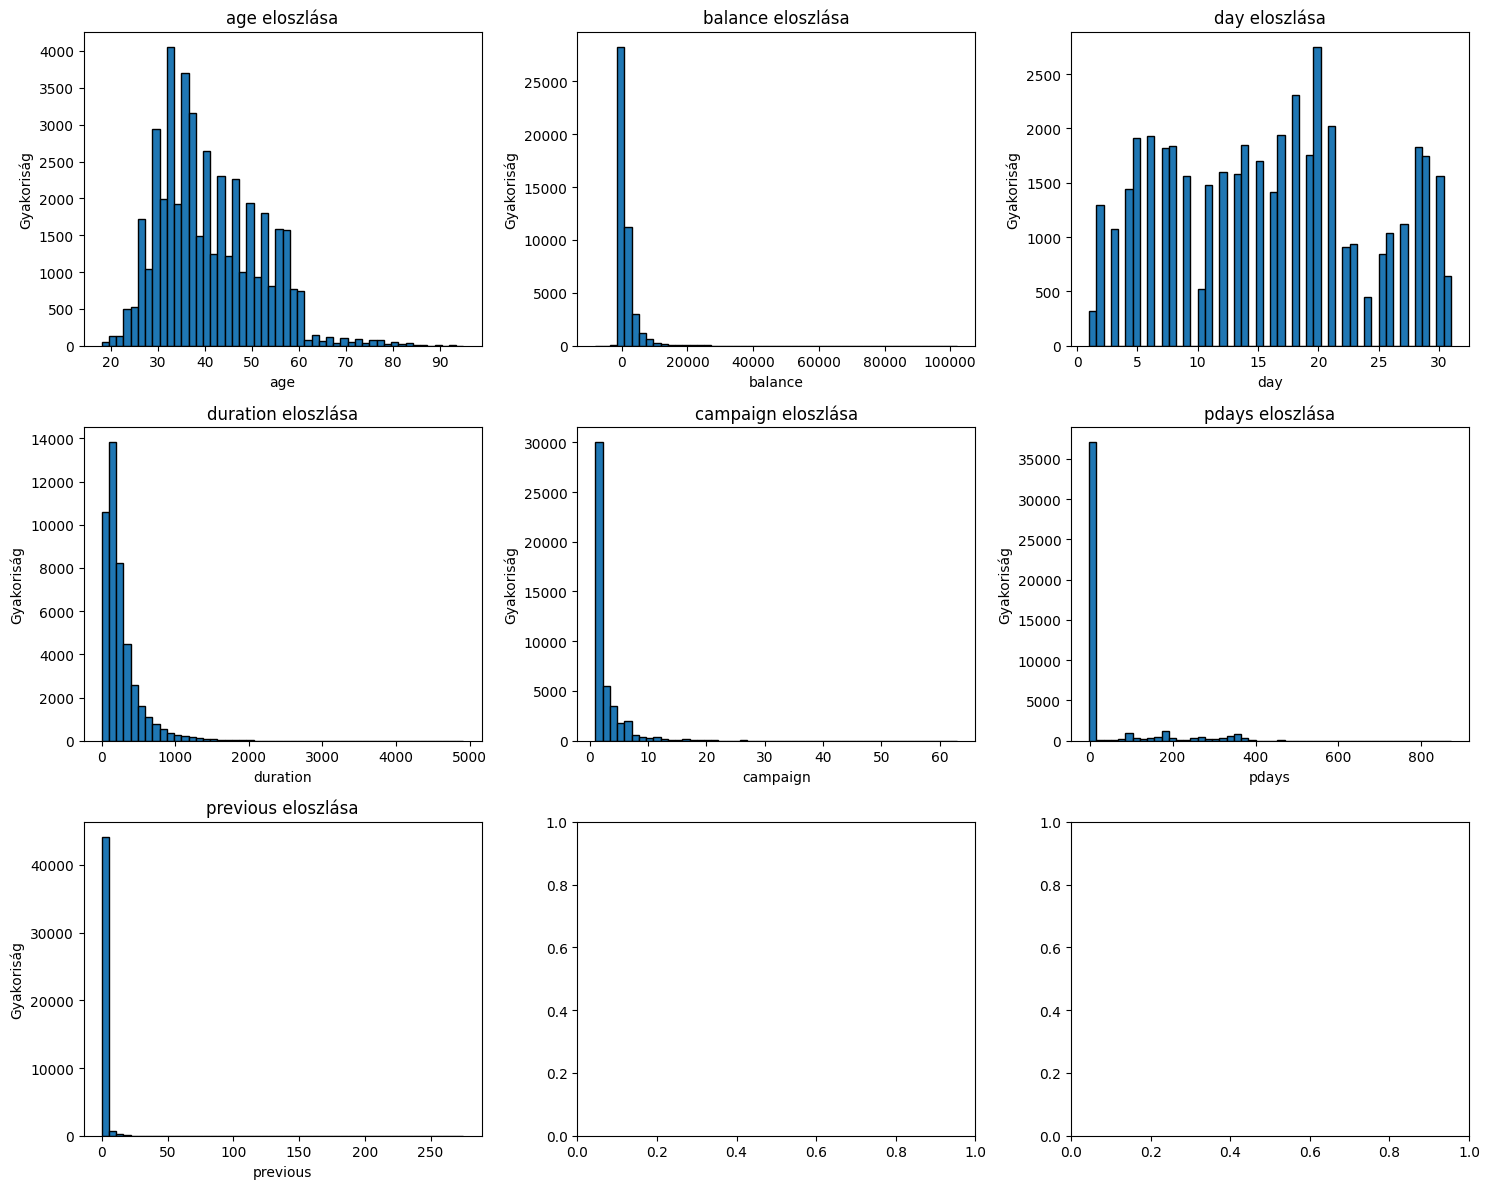

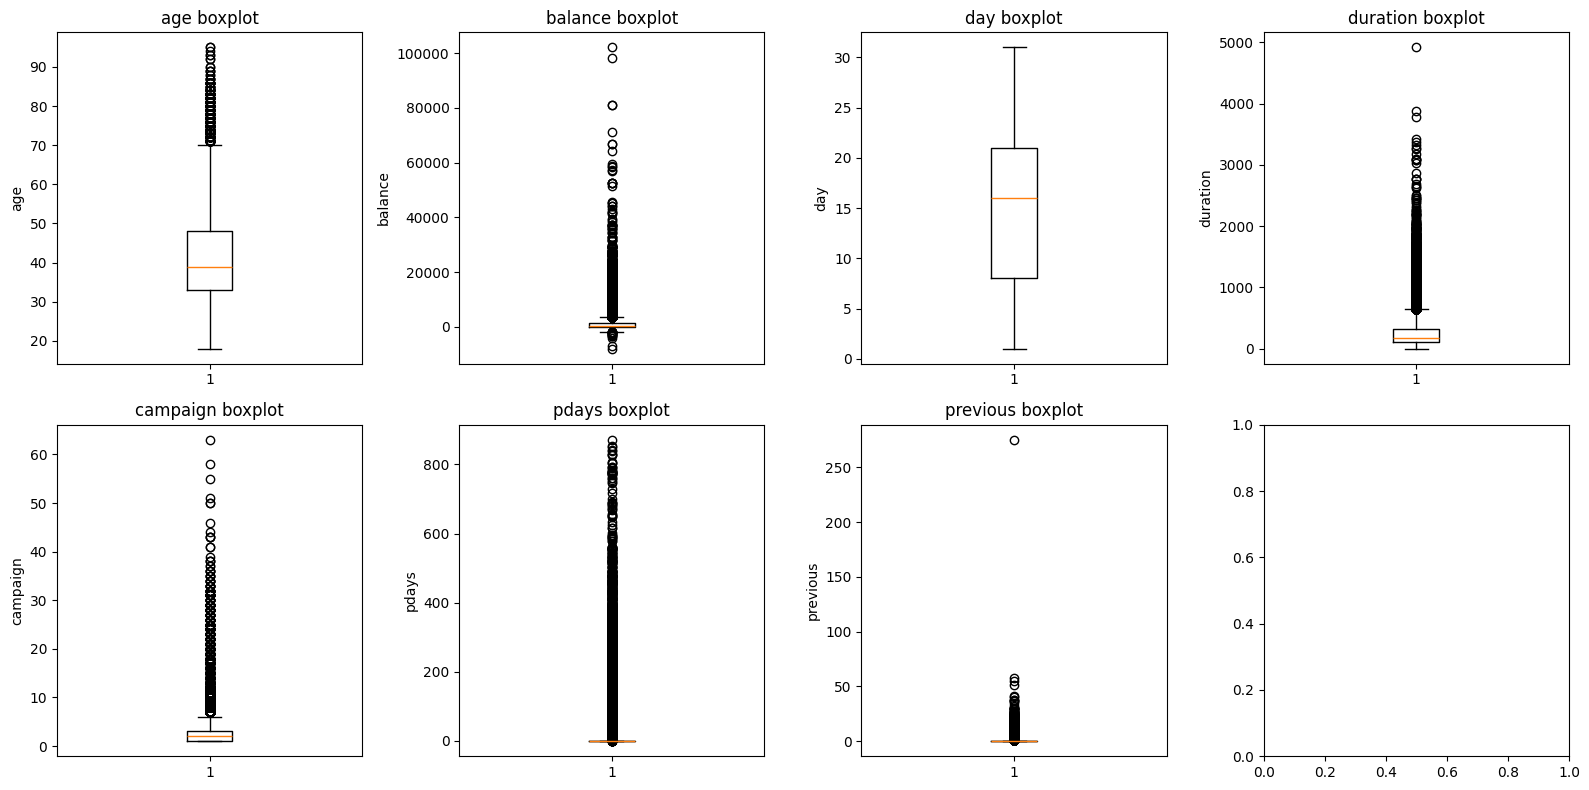

In [6]:
# Numerikus (int64) változók listája
numerikus_valtozok = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

# Eloszlások vizualizációja
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, col in enumerate(numerikus_valtozok):
    axes[idx].hist(ah[col], bins=50, edgecolor='black')
    axes[idx].set_title(f'{col} eloszlása')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Gyakoriság')

plt.tight_layout()
plt.show()

# Boxplot a kiugró értékek vizsgálatára
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for idx, col in enumerate(numerikus_valtozok):
    axes[idx].boxplot(ah[col])
    axes[idx].set_title(f'{col} boxplot')
    axes[idx].set_ylabel(col)

plt.tight_layout()
plt.show()

In [7]:
upper_limit = ah['balance'].quantile(0.95)
ah['balance_capped'] = ah['balance'].clip(upper=upper_limit)

3. Kiugró értékek (outlierek) detektálása

In [8]:
# IQR módszer a kiugró értékek azonosítására
def outlier_detection(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

print("Kiugró értékek száma változónként:")
for col in numerikus_valtozok:
    count, lower, upper = outlier_detection(ah, col)
    print(f"{col}: {count} kiugró érték ({count/len(ah)*100:.2f}%), tartomány: [{lower:.2f}, {upper:.2f}]")

Kiugró értékek száma változónként:
age: 487 kiugró érték (1.08%), tartomány: [10.50, 70.50]
balance: 4729 kiugró érték (10.46%), tartomány: [-1962.00, 3462.00]
day: 0 kiugró érték (0.00%), tartomány: [-11.50, 40.50]
duration: 3235 kiugró érték (7.16%), tartomány: [-221.00, 643.00]
campaign: 3064 kiugró érték (6.78%), tartomány: [-2.00, 6.00]
pdays: 8257 kiugró érték (18.26%), tartomány: [-1.00, -1.00]
previous: 8257 kiugró érték (18.26%), tartomány: [0.00, 0.00]


4. Kategorikus változók elemzése


job eloszlása:
job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64
Egyedi értékek száma: 12

marital eloszlása:
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64
Egyedi értékek száma: 3

education eloszlása:
education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64
Egyedi értékek száma: 4

default eloszlása:
default
no     44396
yes      815
Name: count, dtype: int64
Egyedi értékek száma: 2

housing eloszlása:
housing
yes    25130
no     20081
Name: count, dtype: int64
Egyedi értékek száma: 2

loan eloszlása:
loan
no     37967
yes     7244
Name: count, dtype: int64
Egyedi értékek száma: 2

contact eloszlása:
contact
cellular     29285
unknown      13020
tel

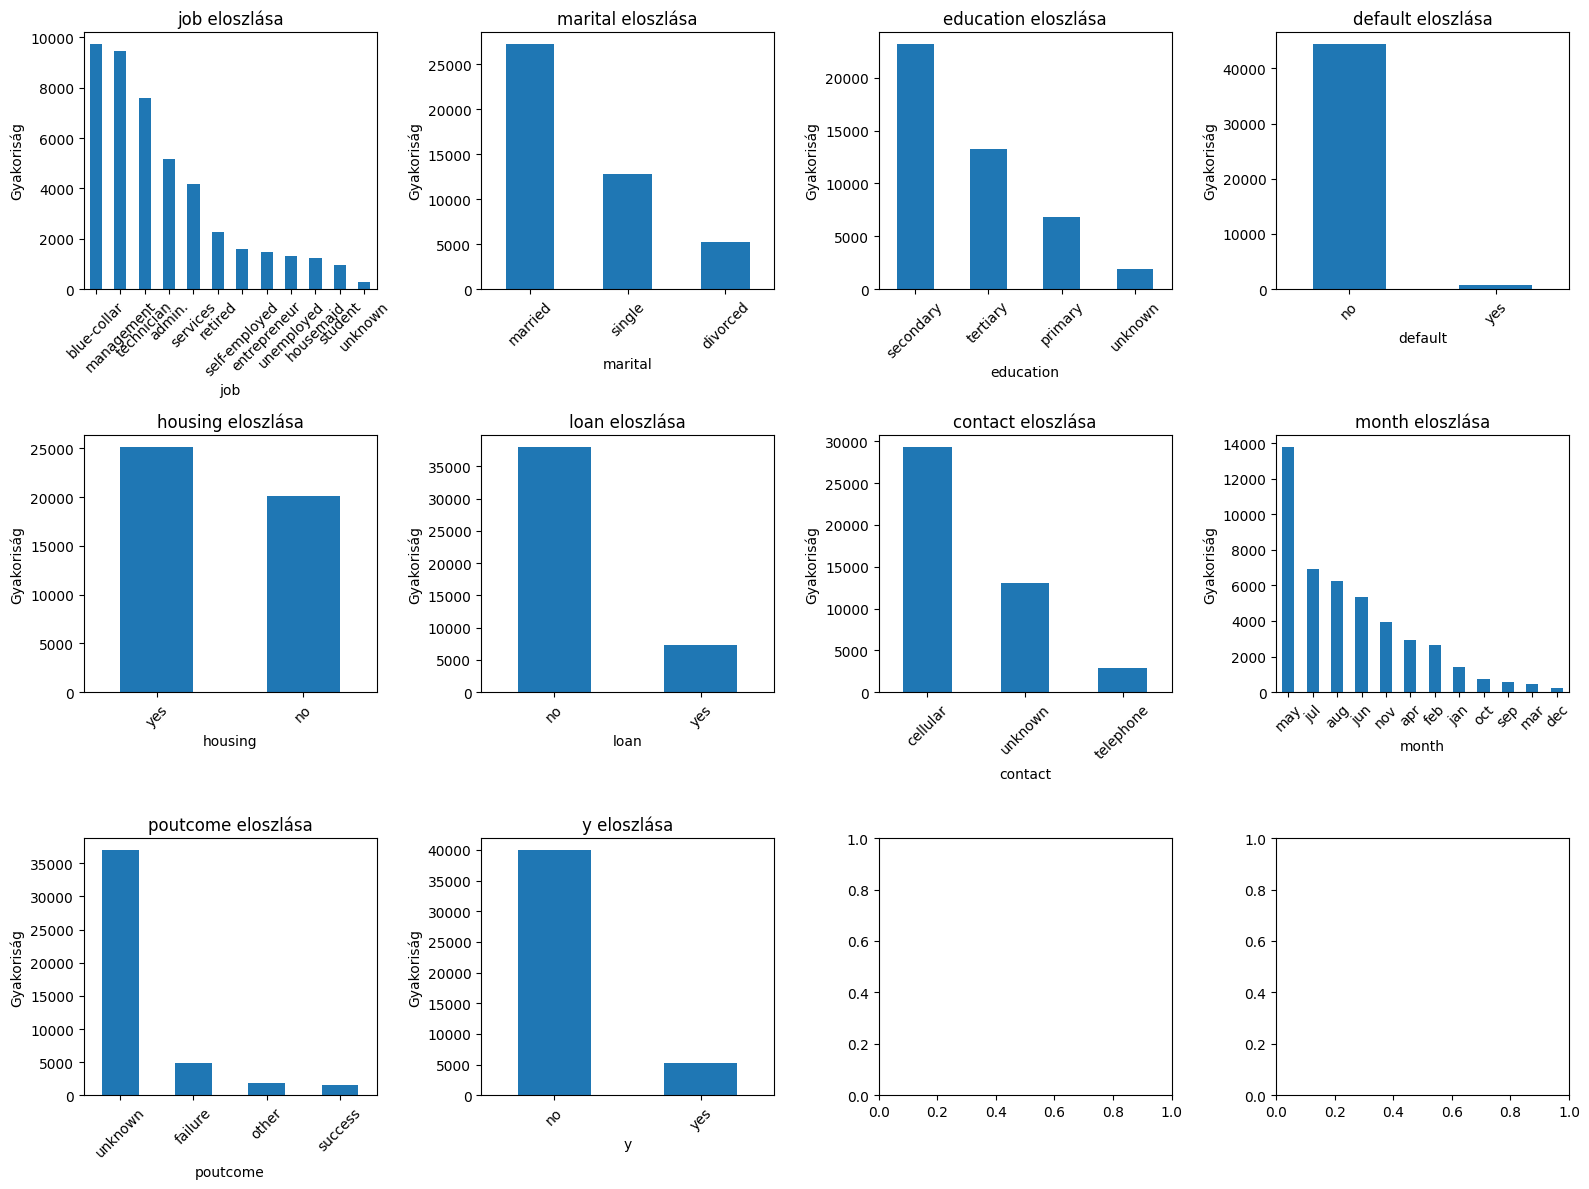

In [9]:
# Összes kategorikus (object) változó eloszlása
kategorikus_valtozok = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']

for col in kategorikus_valtozok:
    print(f"\n{col} eloszlása:")
    print(ah[col].value_counts())
    print(f"Egyedi értékek száma: {ah[col].nunique()}")

# Vizualizáció
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.ravel()

for idx, col in enumerate(kategorikus_valtozok):
    ah[col].value_counts().plot(kind='bar', ax=axes[idx])
    axes[idx].set_title(f'{col} eloszlása')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Gyakoriság')
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [10]:
drop_cols = ['default', 'y']  # default konstans, y célváltozó

5. Korrelációs elemzés

C:\Users\Balázs\AppData\Local\Temp\ipykernel_22436\1957108550.py:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_matrix = correlation_matrix.applymap(lambda x: f"{x:.2f}".replace('.', ','))


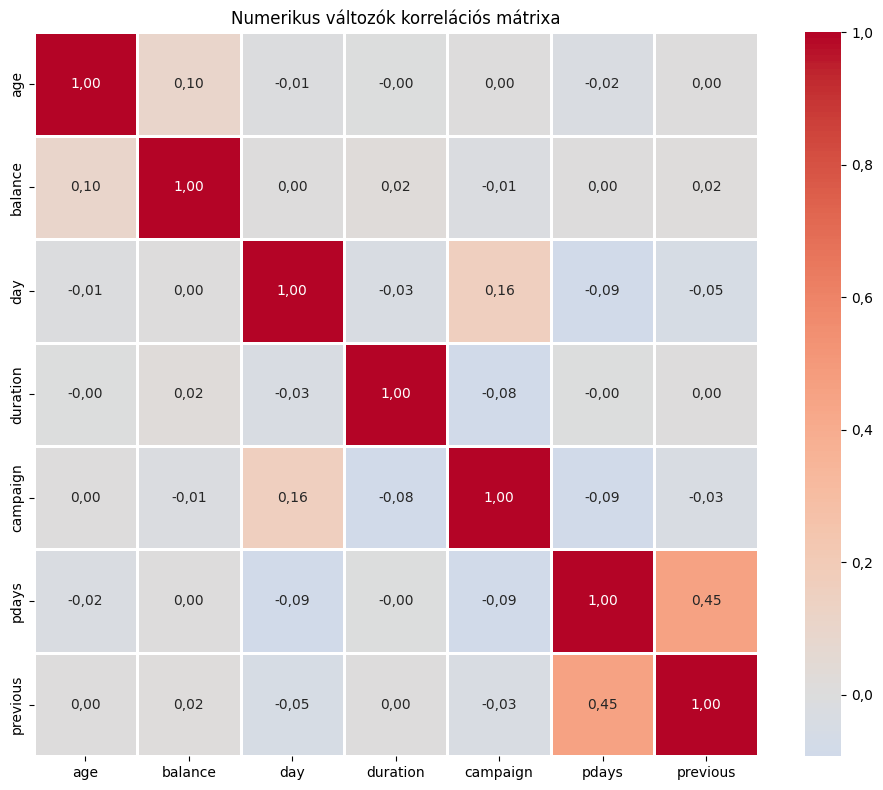


Erős korrelációk (|r| > 0,5):


In [41]:
# Korrelációs mátrix
import matplotlib.ticker as ticker
correlation_matrix = ah[numerikus_valtozok].corr()

annot_matrix = correlation_matrix.applymap(lambda x: f"{x:.2f}".replace('.', ','))

plt.figure(figsize=(10, 8))
ax = sns.heatmap(correlation_matrix, 
            annot=annot_matrix, 
            fmt="",             
            cmap='coolwarm', 
            center=0, 
            square=True, 
            linewidths=1)

cbar = ax.collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x:.1f}".replace('.', ',')))
plt.title('Numerikus változók korrelációs mátrixa')
plt.tight_layout()
plt.show()

print("\nErős korrelációk (|r| > 0,5):")
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        val = correlation_matrix.iloc[i, j]
        if abs(val) > 0.5:
            formatted_val = f"{val:.3f}".replace('.', ',')
            print(f"{correlation_matrix.columns[i]} - {correlation_matrix.columns[j]}: {formatted_val}")

dummy értékek és korreláció

In [12]:
dummies_job     = pd.get_dummies(ah["job"], drop_first=False)
dummies_job     = dummies_job.rename(columns={'unknown':'job_unknown'})
dummies_marital = pd.get_dummies(ah["marital"], drop_first=False)
dummies_marital = dummies_marital.rename(columns={'unknown':'marital_unknown'})
dummies_edu     = pd.get_dummies(ah["education"], drop_first=False)
dummies_edu     = dummies_edu.rename(columns={'unknown':'edu_unknown'})
dummies_month   = pd.get_dummies(ah["month"], drop_first=False)
dummies_contact = pd.get_dummies(ah["contact"], drop_first=False)
dummies_contact = dummies_contact.rename(columns={'unknown':'contact_unknown'})
dummies_poutcome = pd.get_dummies(ah["poutcome"], drop_first=False)
dummies_poutcome = dummies_poutcome.rename(columns={'unknown':'poutcome_unknown'})
dummies_default = pd.get_dummies(ah["default"], drop_first=True)
dummies_default = dummies_default.rename(columns={'yes':'default'})
dummies_housing = pd.get_dummies(ah["housing"], drop_first=True)
dummies_housing = dummies_housing.rename(columns={'yes':'housing'})
dummies_loan    = pd.get_dummies(ah["loan"], drop_first=True)
dummies_loan    = dummies_loan.rename(columns={'yes':'loan'})
dummies_y       = pd.get_dummies(ah["y"], drop_first=True)
dummies_y       = dummies_y.rename(columns={'yes':'y'})

In [13]:
dummies_y

,y
0,False
1,False
2,False
3,False
4,False
...,...
45206,True
45207,True
45208,True
45209,False


In [14]:
dummies_contact
print(dummies_contact.dtypes)

cellular           bool
telephone          bool
contact_unknown    bool
dtype: object


In [15]:
dummies_edu

,primary,secondary,tertiary,edu_unknown
0,False,False,True,False
1,False,True,False,False
2,False,True,False,False
3,False,False,False,True
4,False,False,False,True
...,...,...,...,...
45206,False,False,True,False
45207,True,False,False,False
45208,False,True,False,False
45209,False,True,False,False


In [16]:
dummies_marital

,divorced,married,single
0,False,True,False
1,False,False,True
2,False,True,False
3,False,True,False
4,False,False,True
...,...,...,...
45206,False,True,False
45207,True,False,False
45208,False,True,False
45209,False,True,False


In [17]:
dummies_job

,admin.,blue-collar,entrepreneur,housemaid,management,retired,self-employed,services,student,technician,unemployed,job_unknown
0,False,False,False,False,True,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,True,False,False
2,False,False,True,False,False,False,False,False,False,False,False,False
3,False,True,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
45206,False,False,False,False,False,False,False,False,False,True,False,False
45207,False,False,False,False,False,True,False,False,False,False,False,False
45208,False,False,False,False,False,True,False,False,False,False,False,False
45209,False,True,False,False,False,False,False,False,False,False,False,False


In [18]:
dummies_job.value_counts()

admin.  blue-collar  entrepreneur  housemaid  management  retired  self-employed  services  student  technician  unemployed  job_unknown
False   True         False         False      False       False    False          False     False    False       False       False          9732
        False        False         False      True        False    False          False     False    False       False       False          9458
                                              False       False    False          False     False    True        False       False          7597
True    False        False         False      False       False    False          False     False    False       False       False          5171
False   False        False         False      False       False    False          True      False    False       False       False          4154
                                                          True     False          False     False    False       False       False        

In [19]:
dummies_loan

,loan
0,False
1,False
2,True
3,False
4,False
...,...
45206,False
45207,False
45208,False
45209,False


In [20]:
#dummy-k összesen
all_dummies = pd.concat([dummies_marital, dummies_contact, dummies_default, dummies_edu, dummies_housing, dummies_job, dummies_loan, dummies_month, dummies_poutcome, dummies_y], axis=1)
print(all_dummies.dtypes)

divorced            bool
married             bool
single              bool
cellular            bool
telephone           bool
contact_unknown     bool
default             bool
primary             bool
secondary           bool
tertiary            bool
edu_unknown         bool
housing             bool
admin.              bool
blue-collar         bool
entrepreneur        bool
housemaid           bool
management          bool
retired             bool
self-employed       bool
services            bool
student             bool
technician          bool
unemployed          bool
job_unknown         bool
loan                bool
apr                 bool
aug                 bool
dec                 bool
feb                 bool
jan                 bool
jul                 bool
jun                 bool
mar                 bool
may                 bool
nov                 bool
oct                 bool
sep                 bool
failure             bool
other               bool
success             bool


In [21]:
#korrelációs mátrixhoz tábla összeállítás
ah_wd = ah.join(dummies_marital)
ah_wd = ah_wd.join(dummies_edu)
ah_wd = ah_wd.join(dummies_poutcome)
#ah_wd = ah_wd.drop(['job','marital','education','month'], axis=1)
ah_wd

,age,job,marital,education,default,balance,housing,loan,contact,day,...,married,single,primary,secondary,tertiary,edu_unknown,failure,other,success,poutcome_unknown
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,...,True,False,False,False,True,False,False,False,False,True
1,44,technician,single,secondary,no,29,yes,no,unknown,5,...,False,True,False,True,False,False,False,False,False,True
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,...,True,False,False,True,False,False,False,False,False,True
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,...,True,False,False,False,False,True,False,False,False,True
4,33,unknown,single,unknown,no,1,no,no,unknown,5,...,False,True,False,False,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,...,True,False,False,False,True,False,False,False,False,True
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,...,False,False,True,False,False,False,False,False,False,True
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,...,True,False,False,True,False,False,False,False,True,False
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,...,True,False,False,True,False,False,False,False,False,True


In [22]:
ahd = dummies_marital
ahd = ahd.join(dummies_edu)
ahd = ahd.join(dummies_poutcome)
ahd
dumlist = ahd.columns.to_list()
print(ahd.dtypes)

divorced            bool
married             bool
single              bool
primary             bool
secondary           bool
tertiary            bool
edu_unknown         bool
failure             bool
other               bool
success             bool
poutcome_unknown    bool
dtype: object


In [23]:
num_and_dummies = numerikus_valtozok + dumlist
print(num_and_dummies)


['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'divorced', 'married', 'single', 'primary', 'secondary', 'tertiary', 'edu_unknown', 'failure', 'other', 'success', 'poutcome_unknown']


C:\Users\Balázs\AppData\Local\Temp\ipykernel_22436\2382229711.py:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_matrix = correlation_matrix.applymap(lambda x: f"{x:.2f}".replace('.', ','))


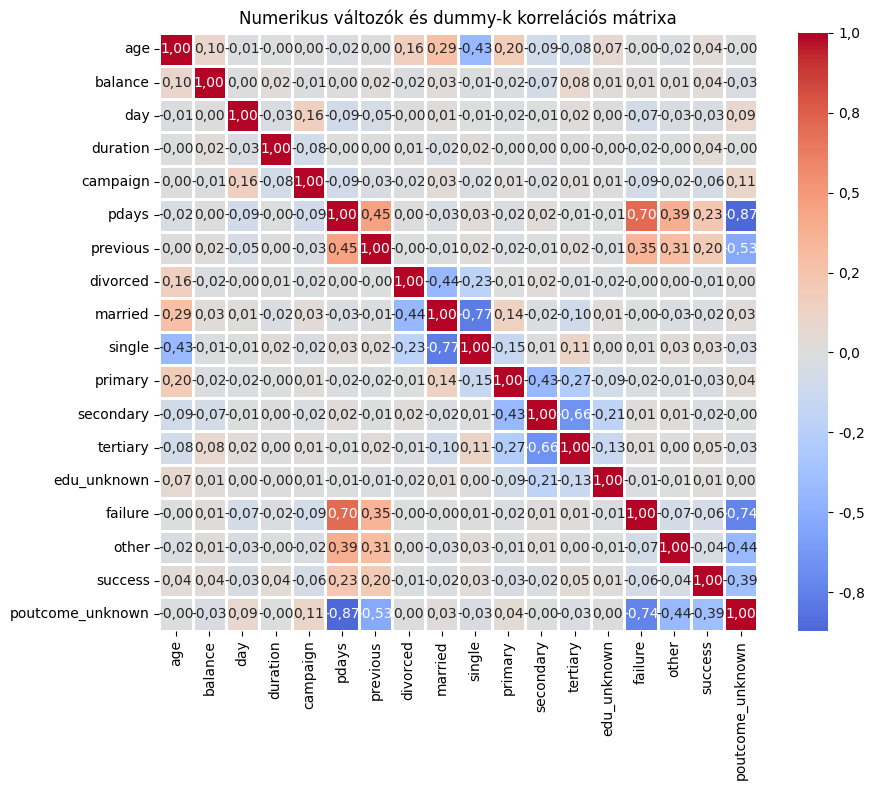


Erős korrelációk (|r| > 0,5):
pdays - failure: 0,701
pdays - poutcome_unknown: -0,870
previous - poutcome_unknown: -0,533
married - single: -0,772
secondary - tertiary: -0,663
failure - poutcome_unknown: -0,738


In [44]:
# Korrelációs mátrix ah_wd
num_and_dummies = numerikus_valtozok + dumlist
correlation_matrix = ah_wd[num_and_dummies].corr()

annot_matrix = correlation_matrix.applymap(lambda x: f"{x:.2f}".replace('.', ','))

plt.figure(figsize=(10, 8))
ax = sns.heatmap(correlation_matrix, 
            annot=annot_matrix, 
            fmt="",             
            cmap='coolwarm', 
            center=0, 
            square=True, 
            linewidths=1)

cbar = ax.collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x:.1f}".replace('.', ',')))
plt.title('Numerikus változók és dummy-k korrelációs mátrixa')
plt.tight_layout()
plt.show()

print("\nErős korrelációk (|r| > 0,5):")
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        val = correlation_matrix.iloc[i, j]
        if abs(val) > 0.5:
            formatted_val = f"{val:.3f}".replace('.', ',')
            print(f"{correlation_matrix.columns[i]} - {correlation_matrix.columns[j]}: {formatted_val}")

6. Változók közötti összefüggések vizsgálata

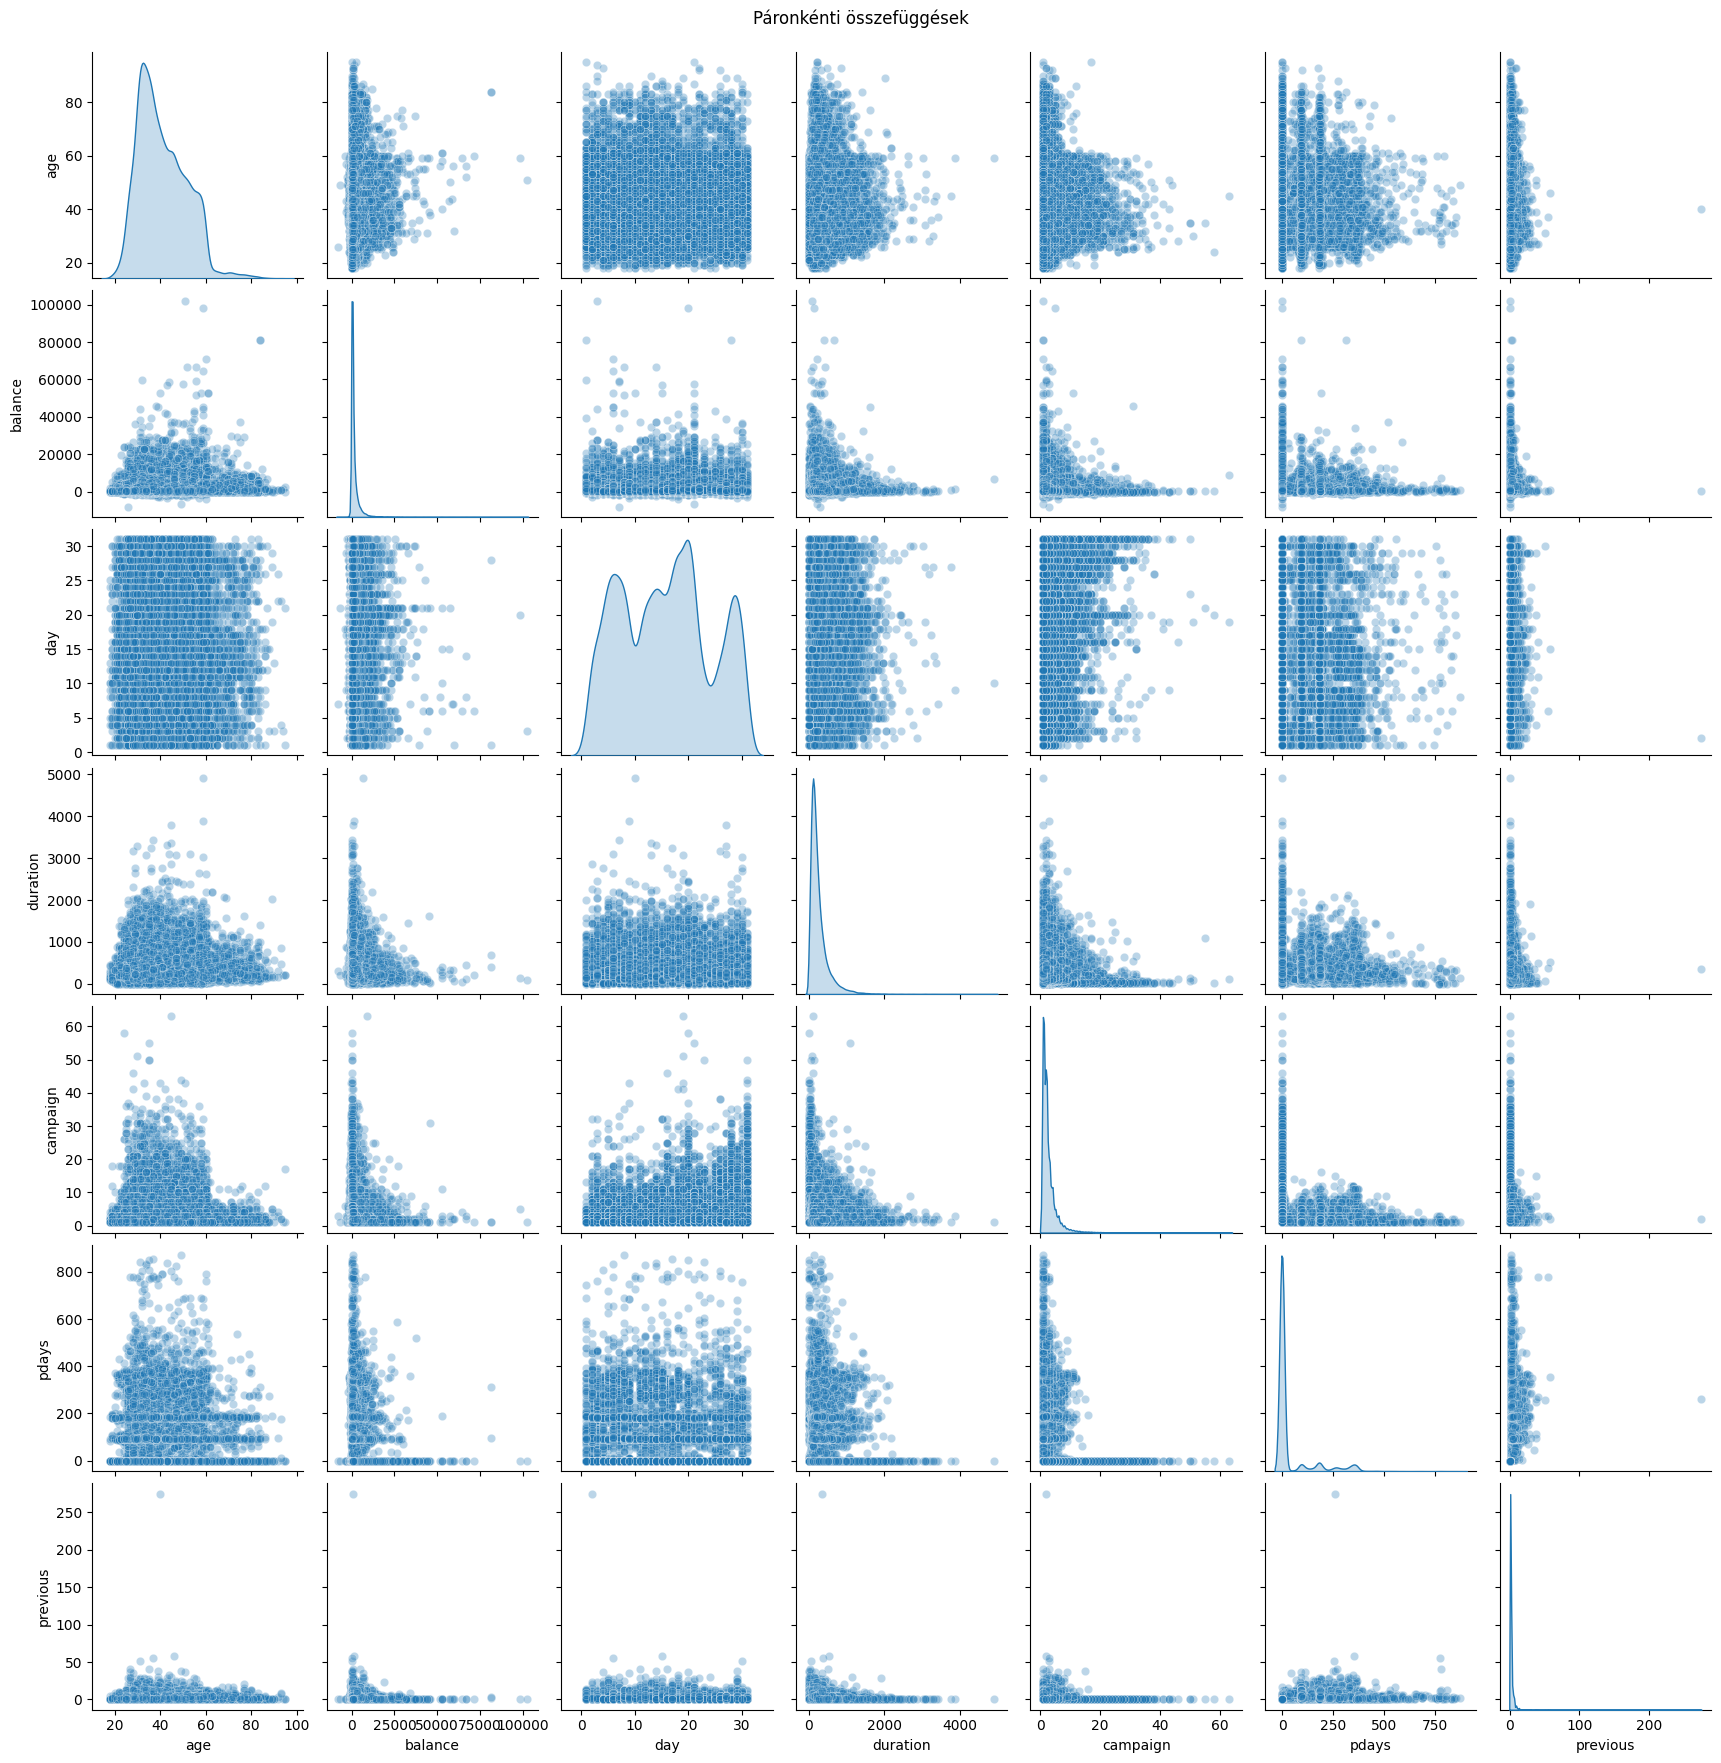

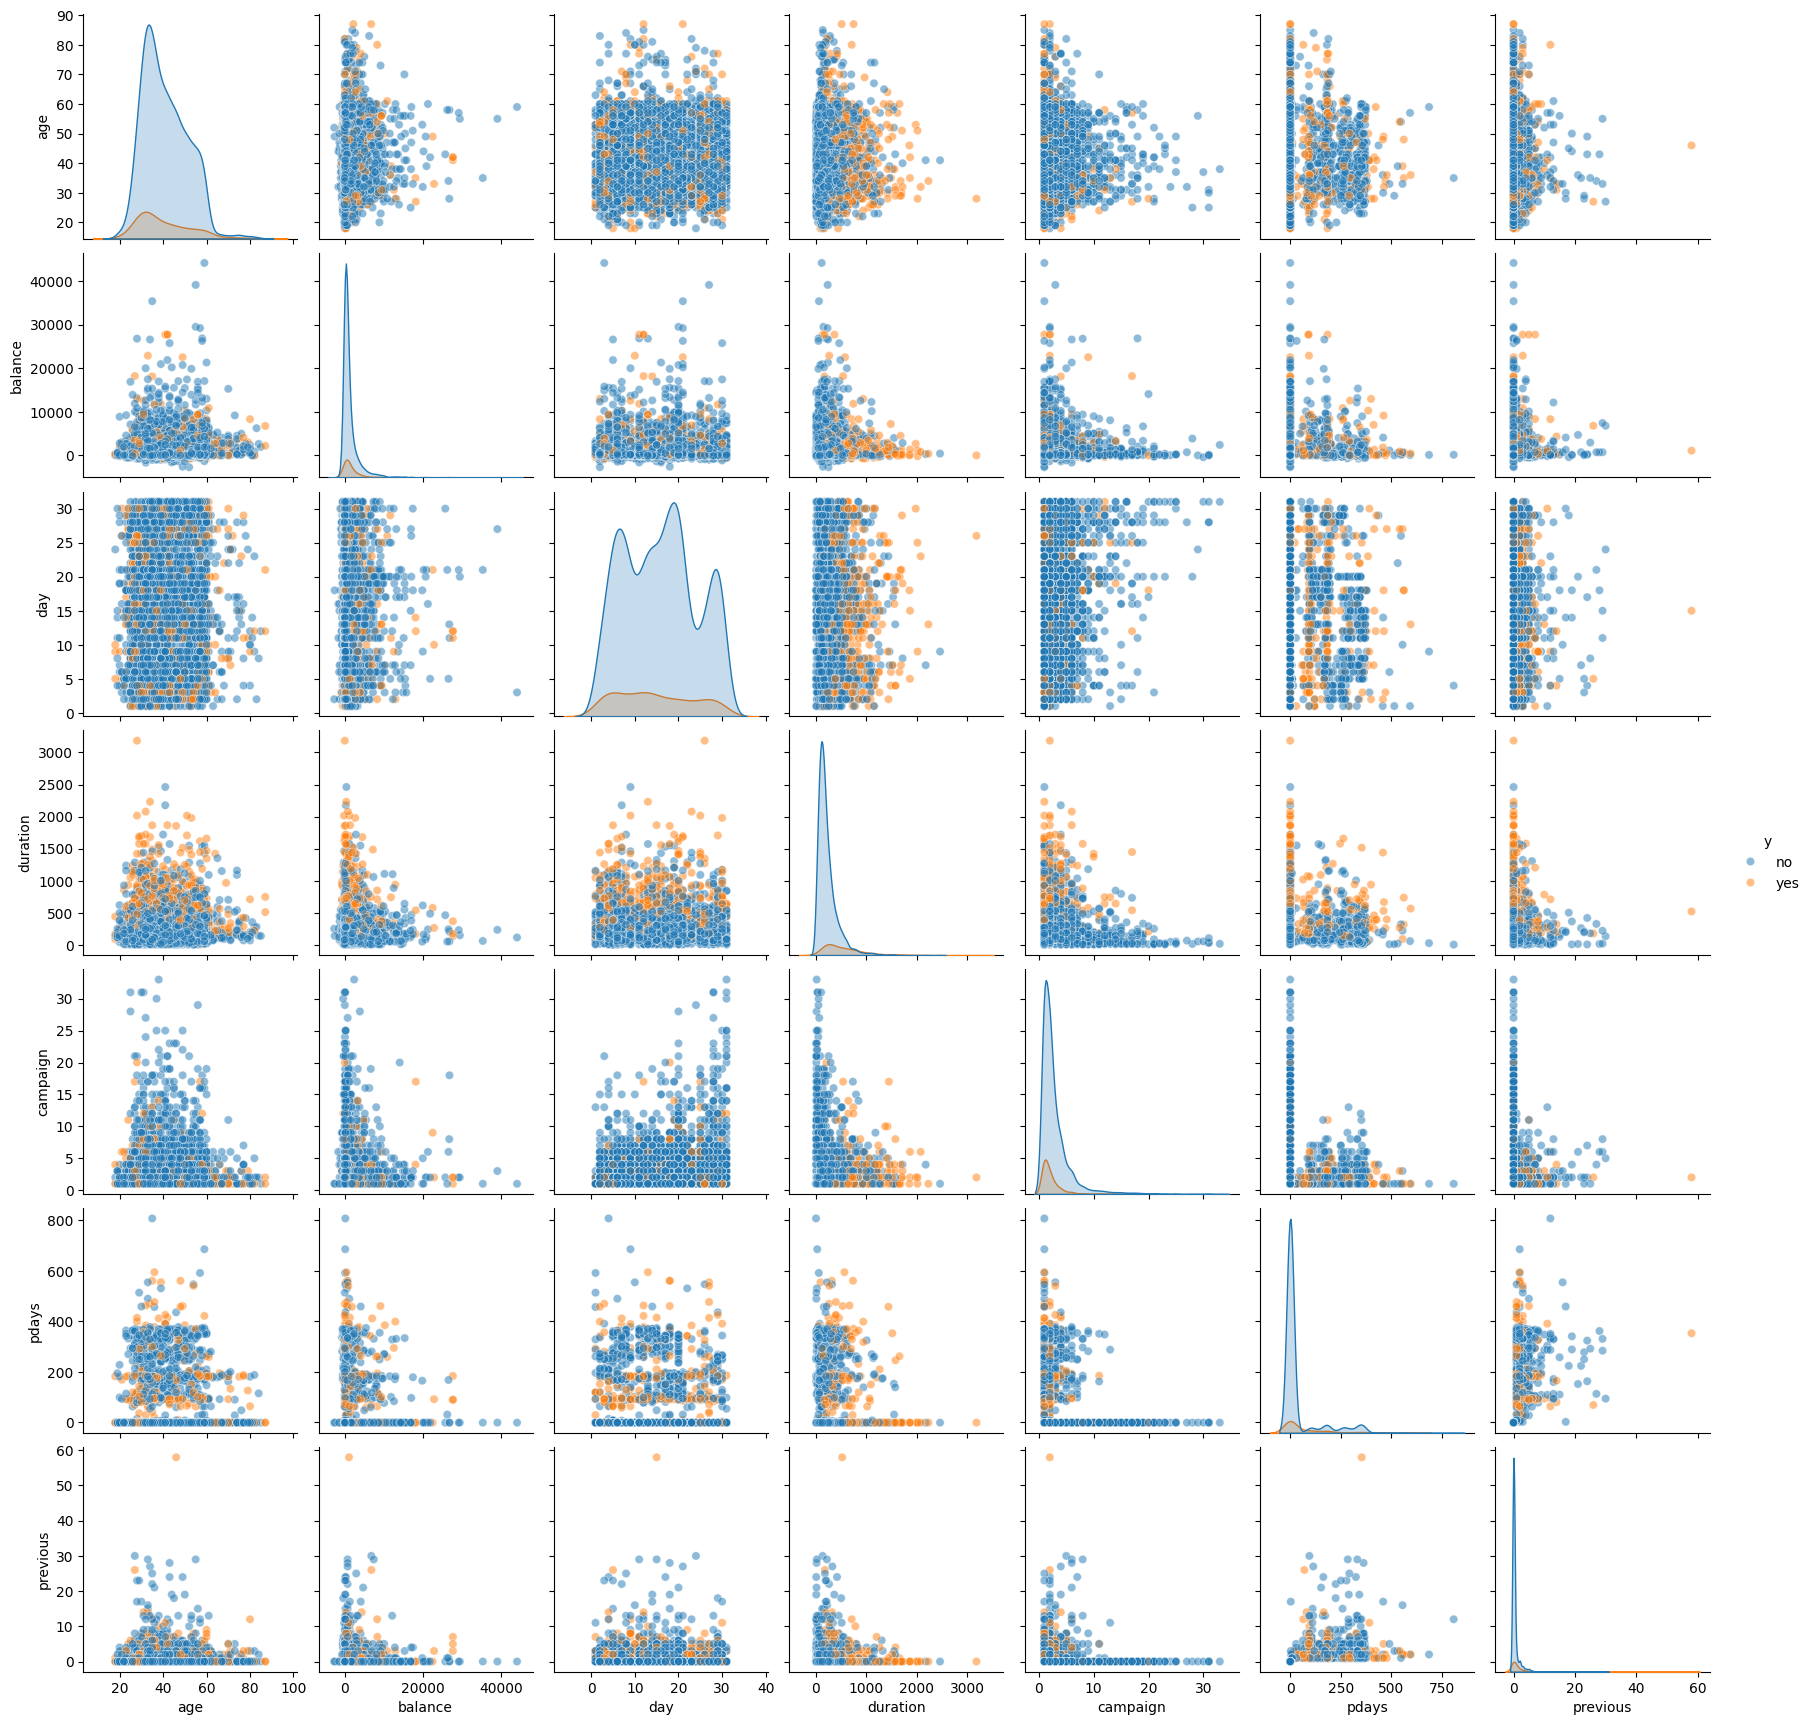

In [25]:
# Páronkénti scatter plotok
sns.pairplot(ah[numerikus_valtozok], diag_kind='kde', plot_kws={'alpha': 0.3})
plt.suptitle('Páronkénti összefüggések', y=1.01)
plt.show()

# Célváltozó szerinti bontás (ha releváns)
ah_sample = ah.sample(n=5000, random_state=42)  # Mintavétel a gyorsabb futásért
sns.pairplot(ah_sample[numerikus_valtozok + ['y']], hue='y', diag_kind='kde', plot_kws={'alpha': 0.5})
plt.show()

In [26]:
import numpy as np
# Log-transzformáció ferde változókhoz
ah['balance_log'] = np.log1p(ah['balance'])  
ah['duration_log'] = np.log1p(ah['duration'])

# Vagy Winsorization (1-99 percentilis)
from scipy.stats.mstats import winsorize
ah['balance_win'] = winsorize(ah['balance'], limits=[0.01, 0.01])
ah['duration_win'] = winsorize(ah['duration'], limits=[0.01, 0.01])

c:\Users\Balázs\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\Balázs\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [27]:
print(ah['balance_win'].describe())

count    45211.000000
mean      1278.122691
std       2249.412265
min       -627.000000
25%         72.000000
50%        448.000000
75%       1428.000000
max      13165.000000
Name: balance_win, dtype: float64


c:\Users\Balázs\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:4968: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


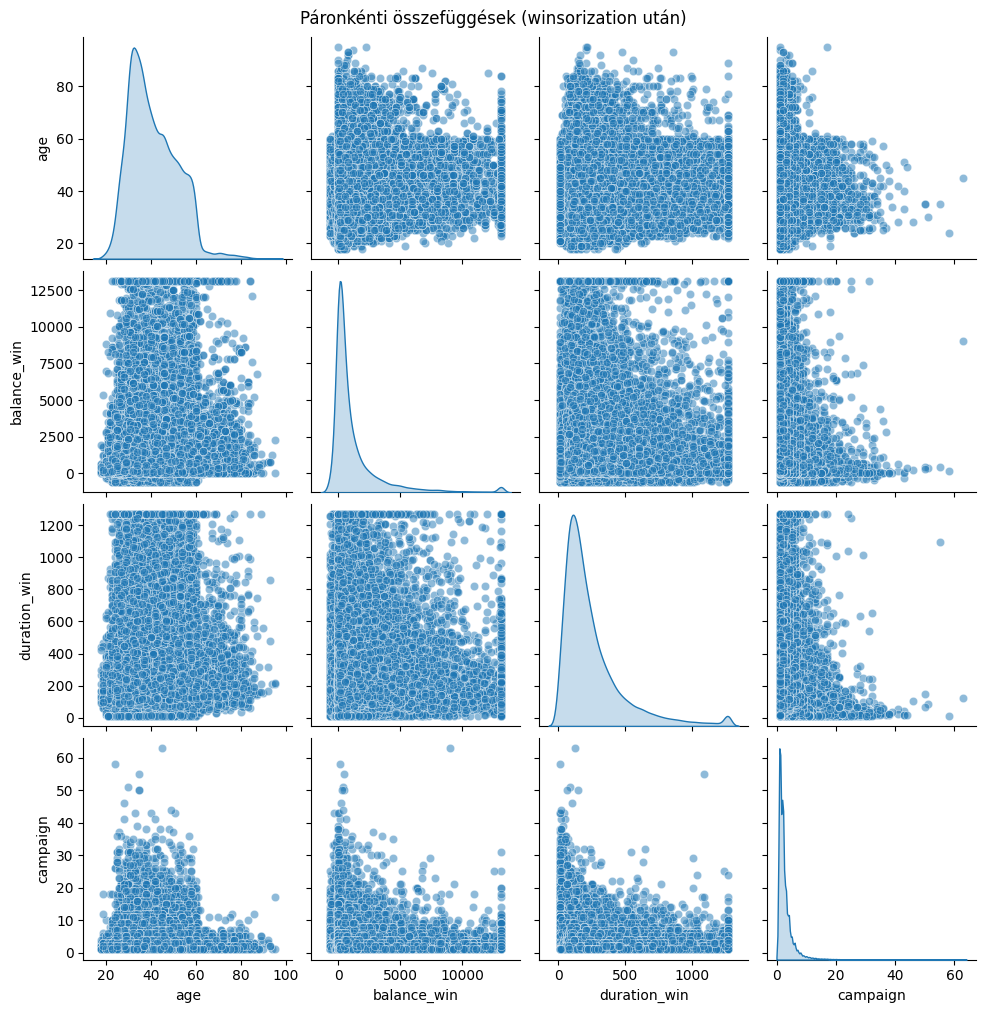

In [28]:
# Winsorization után teljes scatterplot
import seaborn as sns

final_X_pca = ['age', 'balance_win', 'duration_win', 'campaign']
sns.pairplot(ah[final_X_pca], diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Páronkénti összefüggések (winsorization után)', y=1.01)
plt.show()

7. Skálázás szükségességének vizsgálata

In [29]:
# Változók tartományának összehasonlítása
print("Változók statisztikái (skálázás előtt):")
print(ah[numerikus_valtozok].describe())

# Coefficient of Variation (variációs együttható)
print("\nVariációs együtthatók:")
for col in numerikus_valtozok:
    cv = (ah[col].std() / ah[col].mean()) * 100
    print(f"{col}: {cv:.2f}%")

Változók statisztikái (skálázás előtt):
                age        balance           day      duration      campaign  \
count  45211.000000   45211.000000  45211.000000  45211.000000  45211.000000   
mean      40.936210    1362.272058     15.806419    258.163080      2.763841   
std       10.618762    3044.765829      8.322476    257.527812      3.098021   
min       18.000000   -8019.000000      1.000000      0.000000      1.000000   
25%       33.000000      72.000000      8.000000    103.000000      1.000000   
50%       39.000000     448.000000     16.000000    180.000000      2.000000   
75%       48.000000    1428.000000     21.000000    319.000000      3.000000   
max       95.000000  102127.000000     31.000000   4918.000000     63.000000   

              pdays      previous  
count  45211.000000  45211.000000  
mean      40.197828      0.580323  
std      100.128746      2.303441  
min       -1.000000      0.000000  
25%       -1.000000      0.000000  
50%       -1.000000    

8. Feature Engineering megfontolások

In [30]:
# 1. AGE: Életszakasz alapú (üzleti logika)
ah['age_lifecycle'] = pd.cut(ah['age'], 
                             bins=[0, 25, 35, 45, 55, 65, 100],
                             labels=['Kezdő (18-25)', 
                                    'Építő (26-35)', 
                                    'Vagyonfelhalmozó (36-45)', 
                                    'Konszolidáló (46-55)', 
                                    'Előnyugdíjas (56-65)', 
                                    'Nyugdíjas (65+)'])

# 2. BALANCE: Realisztikus banki kategóriák
ah['balance_realistic'] = pd.cut(ah['balance'], 
                                 bins=[-float('inf'), -100, 0, 500, 2000, 10000, 50000, float('inf')],
                                 labels=['Hiteltartozás', 
                                        'Nulla körüli', 
                                        'Minimal (<500€)', 
                                        'Alacsony (500-2K€)', 
                                        'Közepes (2-10K€)', 
                                        'Prémium (10-50K€)', 
                                        'VIP (50K€+)'])

# Eloszlások megjelenítése
print("=" * 13)
print(" Új változók")
print("=" * 13)

print("\n1. Életszakasz alapú (age_lifecycle):")
print(ah['age_lifecycle'].value_counts().sort_index())
print(f"   → {ah['age_lifecycle'].value_counts().min()} - {ah['age_lifecycle'].value_counts().max()} ügyfél/kategória")

print("\n2. Realisztikus banki kategóriák (balance_realistic):")
print(ah['balance_realistic'].value_counts().sort_index())
print(f"   → {ah['balance_realistic'].value_counts().min()} - {ah['balance_realistic'].value_counts().max()} ügyfél/kategória")

 Új változók

1. Életszakasz alapú (age_lifecycle):
age_lifecycle
Kezdő (18-25)                1336
Építő (26-35)               15571
Vagyonfelhalmozó (36-45)    13856
Konszolidáló (46-55)         9548
Előnyugdíjas (56-65)         4149
Nyugdíjas (65+)               751
Name: count, dtype: int64
   → 751 - 15571 ügyfél/kategória

2. Realisztikus banki kategóriák (balance_realistic):
balance_realistic
Hiteltartozás          2757
Nulla körüli           4523
Minimal (<500€)       16385
Alacsony (500-2K€)    13045
Közepes (2-10K€)       7672
Prémium (10-50K€)       811
VIP (50K€+)              18
Name: count, dtype: int64
   → 18 - 16385 ügyfél/kategória


In [31]:
# =====================================
# VÉGLEGES AJÁNLOTT KATEGORIZÁLÁS
# =====================================

# 1. Életszakasz alapú (age_lifecycle) - MEGTARTOD
ah['age_lifecycle'] = pd.cut(ah['age'], 
                             bins=[0, 25, 35, 45, 55, 65, 100],
                             labels=['Starter (18-25)', 
                                    'Builder (26-35)', 
                                    'Accumulator (36-45)', 
                                    'Consolidator (46-55)', 
                                    'Pre-Retirement (56-65)', 
                                    'Retirement (65+)'])

# 2. Percentilis alapú (balance_percentile) - CSERÉLD LE
ah['balance_percentile'] = pd.qcut(ah['balance'], 
                                   q=[0, 0.25, 0.5, 0.75, 0.9, 1.0],
                                   labels=['Alsó 25%', 
                                          'Alsó-közép 25%', 
                                          'Középső 25%', 
                                          'Felső-közép 15%', 
                                          'Felső 10%'],
                                   duplicates='drop')  # Ha egyedi értékek problémát okoznának

# Eloszlások és határértékek
print("=" * 70)
print("VÉGLEGES KATEGORIZÁLÁS - ELOSZLÁSOK")
print("=" * 70)

print("\n1. Életszakasz alapú (age_lifecycle):")
age_dist = ah['age_lifecycle'].value_counts().sort_index()
for cat, count in age_dist.items():
    print(f"  {cat:<30} {count:>6} ({count/len(ah)*100:>5.1f}%)")

print("\n2. Percentilis alapú (balance_percentile):")
balance_dist = ah['balance_percentile'].value_counts().sort_index()
for cat, count in balance_dist.items():
    print(f"  {cat:<30} {count:>6} ({count/len(ah)*100:>5.1f}%)")

# Percentilis határértékek részletezése
print("\n   Percentilis határértékek:")
quantiles, bins = pd.qcut(ah['balance'], q=[0, 0.25, 0.5, 0.75, 0.9, 1.0], retbins=True, duplicates='drop')
labels_detailed = ['Alsó 25%', 'Alsó-közép 25%', 'Felső-közép 25%', 'Felső 15%', 'Top 10%']
for i in range(len(bins)-1):
    print(f"   {labels_detailed[i]:<20} {bins[i]:>8.0f} - {bins[i+1]:>8.0f} €")

# Összehasonlítás az eredeti balance_realistic-kal
print("\n" + "=" * 70)
print("ÖSSZEHASONLÍTÁS: balance_realistic vs. balance_percentile")
print("=" * 70)

comparison_df = pd.DataFrame({
    'balance_realistic': ah['balance_realistic'].value_counts().sort_index(),
    'balance_percentile': ah['balance_percentile'].value_counts().sort_index()
})
print(comparison_df)

print("\n→ A percentilis alapú egyenletesebb eloszlást biztosít!")

VÉGLEGES KATEGORIZÁLÁS - ELOSZLÁSOK

1. Életszakasz alapú (age_lifecycle):
  Starter (18-25)                  1336 (  3.0%)
  Builder (26-35)                 15571 ( 34.4%)
  Accumulator (36-45)             13856 ( 30.6%)
  Consolidator (46-55)             9548 ( 21.1%)
  Pre-Retirement (56-65)           4149 (  9.2%)
  Retirement (65+)                  751 (  1.7%)

2. Percentilis alapú (balance_percentile):
  Alsó 25%                        11317 ( 25.0%)
  Alsó-közép 25%                  11291 ( 25.0%)
  Középső 25%                     11306 ( 25.0%)
  Felső-közép 15%                  6776 ( 15.0%)
  Felső 10%                        4521 ( 10.0%)

   Percentilis határértékek:
   Alsó 25%                -8019 -       72 €
   Alsó-közép 25%             72 -      448 €
   Felső-közép 25%           448 -     1428 €
   Felső 15%                1428 -     3574 €
   Top 10%                  3574 -   102127 €

ÖSSZEHASONLÍTÁS: balance_realistic vs. balance_percentile
                    bal

9. Dimenzionalitás előzetes vizsgálata

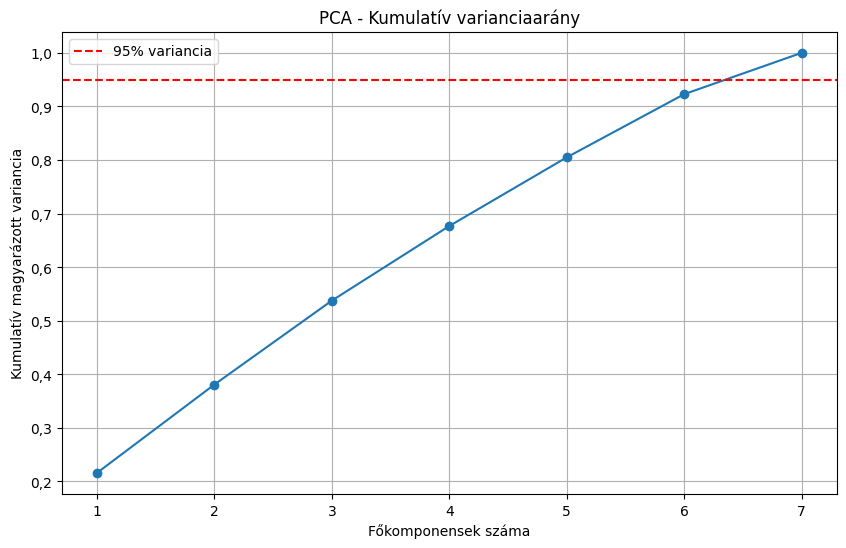

Főkomponensek által magyarázott variancia:
PC1: 0.2156 (21.56%)
PC2: 0.1650 (16.50%)
PC3: 0.1567 (15.67%)
PC4: 0.1393 (13.93%)
PC5: 0.1282 (12.82%)
PC6: 0.1180 (11.80%)
PC7: 0.0772 (7.72%)
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


In [38]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Standardizálás
scaler = StandardScaler()
ah_scaled = scaler.fit_transform(ah[numerikus_valtozok])

# PCA a varianciaarány megértéséhez
pca = PCA()
pca.fit(ah_scaled)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), 
         pca.explained_variance_ratio_.cumsum(), marker='o')
plt.xlabel('Főkomponensek száma')
plt.ylabel('Kumulatív magyarázott variancia')
plt.gca().yaxis.set_major_formatter(FuncFormatter(comma_formatter))
plt.title('PCA - Kumulatív varianciaarány')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variancia')
plt.legend()
plt.show()

print("Főkomponensek által magyarázott variancia:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {var:.4f} ({var*100:.2f}%)")
print(numerikus_valtozok)

PCA EREDMÉNYEK (age és balance)

Főkomponensek által magyarázott variancia:
PC1: 0.5489 (54.89%)
PC2: 0.4511 (45.11%)

Kumulatív variancia:
PC1-PC1: 0.5489 (54.89%)
PC1-PC2: 1.0000 (100.00%)


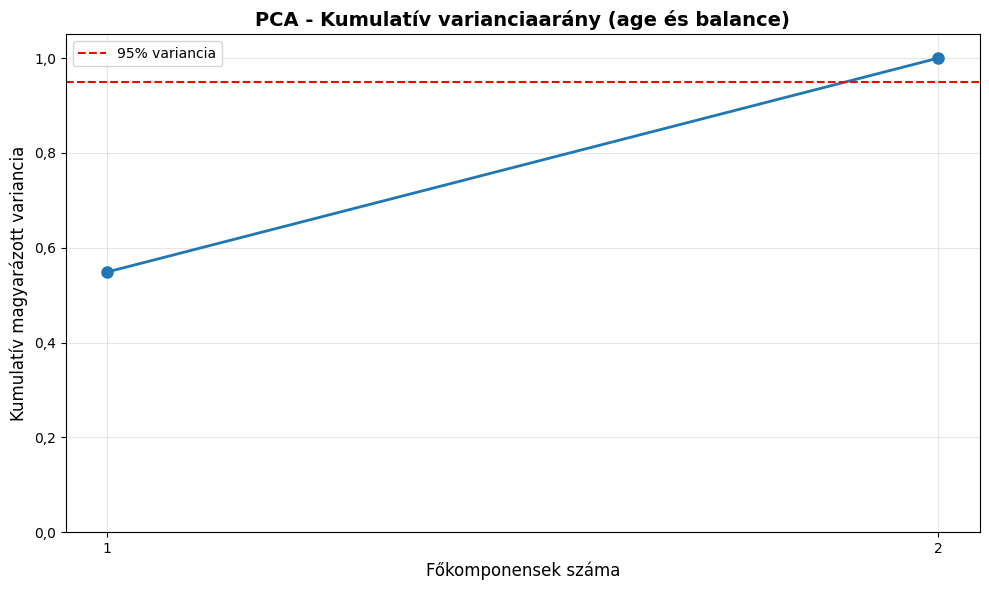

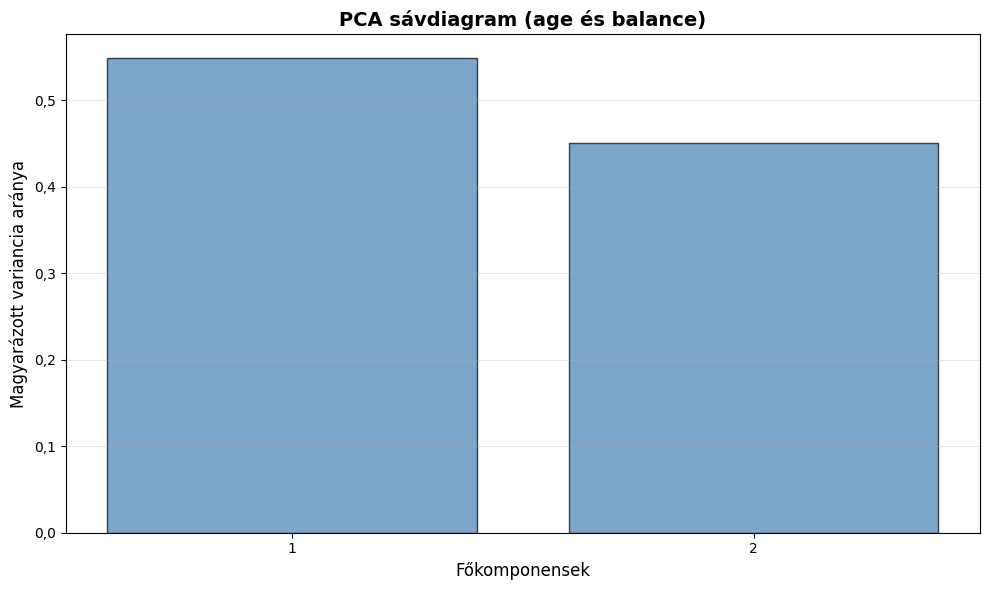

In [37]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# =====================================
# PCA CSAK age ÉS balance-RA
# =====================================

# 1. Standardizálás
scaler = StandardScaler()
X_scaled = scaler.fit_transform(ah[['age', 'balance']])

# 2. PCA
pca = PCA()
pca.fit(X_scaled)

# 3. Varianciaarányok
print("=" * 60)
print("PCA EREDMÉNYEK (age és balance)")
print("=" * 60)
print("\nFőkomponensek által magyarázott variancia:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {var:.4f} ({var*100:.2f}%)")

print(f"\nKumulatív variancia:")
cumsum = np.cumsum(pca.explained_variance_ratio_)
for i, cum in enumerate(cumsum):
    print(f"PC1-PC{i+1}: {cum:.4f} ({cum*100:.2f}%)")

# 4. Vizualizáció - Kumulatív varianciaarány
# Y tengely formázó alkalmazása
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumsum) + 1), cumsum, marker='o', linewidth=2, markersize=8)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variancia')
plt.xlabel('Főkomponensek száma', fontsize=12)
plt.ylabel('Kumulatív magyarázott variancia', fontsize=12)
plt.gca().yaxis.set_major_formatter(FuncFormatter(comma_formatter))
plt.title('PCA - Kumulatív varianciaarány (age és balance)', fontsize=14, fontweight='bold')
plt.xticks(range(1, len(cumsum) + 1))
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 5. Vizualizáció - Egyedi varianciaarányok
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), 
        pca.explained_variance_ratio_, 
        alpha=0.7, 
        color='steelblue',
        edgecolor='black')
plt.xlabel('Főkomponensek', fontsize=12)
plt.ylabel('Magyarázott variancia aránya', fontsize=12)
plt.gca().yaxis.set_major_formatter(FuncFormatter(comma_formatter))
plt.title('PCA sávdiagram (age és balance)', fontsize=14, fontweight='bold')
plt.xticks(range(1, len(pca.explained_variance_ratio_) + 1))
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

PCA EREDMÉNYEK (age és balance_win)

Főkomponensek által magyarázott variancia:
PC1: 0.5526 (55.26%)
PC2: 0.4474 (44.74%)

Kumulatív variancia:
PC1-PC1: 0.5526 (55.26%)
PC1-PC2: 1.0000 (100.00%)


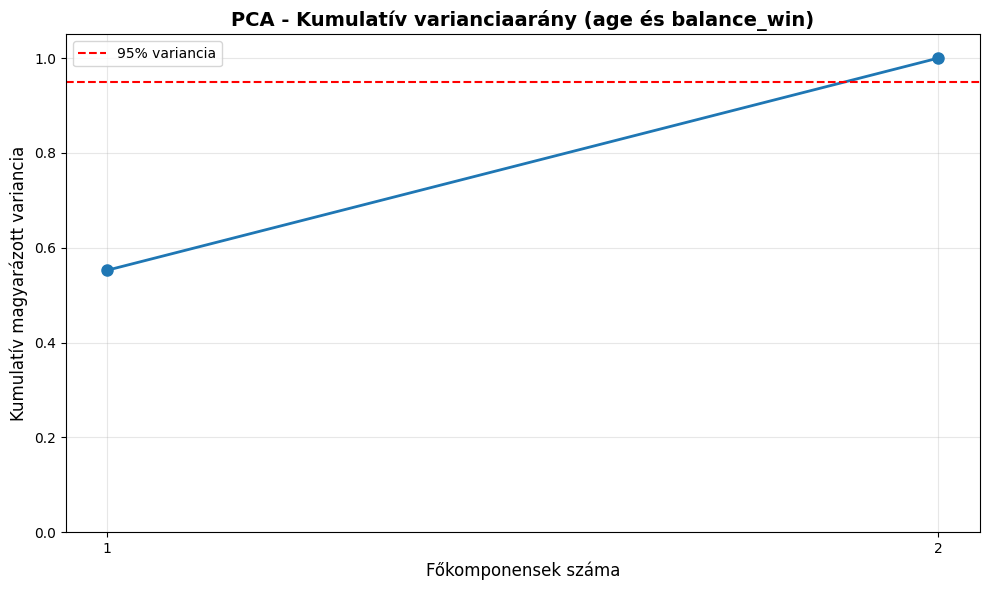

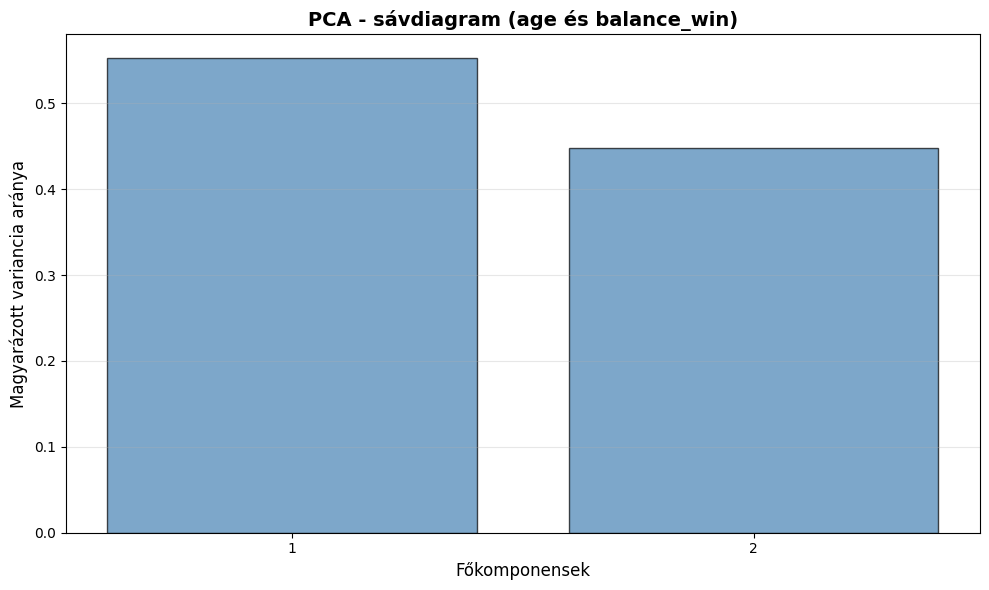

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# =====================================
# PCA CSAK age ÉS balance_win-re
# =====================================

# 1. Standardizálás
scaler = StandardScaler()
X_scaled = scaler.fit_transform(ah[['age', 'balance_win']])

# 2. PCA
pca = PCA()
pca.fit(X_scaled)

# 3. Varianciaarányok
print("=" * 60)
print("PCA EREDMÉNYEK (age és balance_win)")
print("=" * 60)
print("\nFőkomponensek által magyarázott variancia:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {var:.4f} ({var*100:.2f}%)")

print(f"\nKumulatív variancia:")
cumsum = np.cumsum(pca.explained_variance_ratio_)
for i, cum in enumerate(cumsum):
    print(f"PC1-PC{i+1}: {cum:.4f} ({cum*100:.2f}%)")

# 4. Vizualizáció - Kumulatív varianciaarány
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumsum) + 1), cumsum, marker='o', linewidth=2, markersize=8)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variancia')
plt.xlabel('Főkomponensek száma', fontsize=12)
plt.ylabel('Kumulatív magyarázott variancia', fontsize=12)
plt.gca().yaxis.set_major_formatter(FuncFormatter(comma_formatter))
plt.title('PCA - Kumulatív varianciaarány (age és balance_win)', fontsize=14, fontweight='bold')
plt.xticks(range(1, len(cumsum) + 1))
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 5. Vizualizáció - Egyedi varianciaarányok
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), 
        pca.explained_variance_ratio_, 
        alpha=0.7, 
        color='steelblue',
        edgecolor='black')
plt.xlabel('Főkomponensek', fontsize=12)
plt.ylabel('Magyarázott variancia aránya', fontsize=12)
plt.gca().yaxis.set_major_formatter(FuncFormatter(comma_formatter))
plt.title('PCA - sávdiagram (age és balance_win)', fontsize=14, fontweight='bold')
plt.xticks(range(1, len(pca.explained_variance_ratio_) + 1))
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

klaszterezések tesztelése, összehasonlítása

In [34]:
#klaszterezés, változók felmérése
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.cluster import KMeans

# 3 változó
features_3 = ['age', 'balance_win', 'duration_win']
X_3 = StandardScaler().fit_transform(ah[features_3])
km_3 = KMeans(n_clusters=3, random_state=42).fit(X_3)

# 5 változó
features_5 = ['age', 'balance_win', 'duration_win', 'campaign', 'previous']
X_5 = StandardScaler().fit_transform(ah[features_5])
km_5 = KMeans(n_clusters=3, random_state=42).fit(X_5)

# 7 változó
features_7 = ['age', 'balance_win', 'day', 'duration_win', 'campaign', 'pdays', 'previous']
X_7 = StandardScaler().fit_transform(ah[features_7])
km_7 = KMeans(n_clusters=3, random_state=42).fit(X_7)

# Összehasonlítás
results = pd.DataFrame({
    'Változók száma': [3, 5, 7],
    'Silhouette Score': [
        silhouette_score(X_3, km_3.labels_),
        silhouette_score(X_5, km_5.labels_),
        silhouette_score(X_7, km_7.labels_)
    ],
    'Davies-Bouldin': [
        davies_bouldin_score(X_3, km_3.labels_),
        davies_bouldin_score(X_5, km_5.labels_),
        davies_bouldin_score(X_7, km_7.labels_)
    ]
})

print(results)

   Változók száma  Silhouette Score  Davies-Bouldin
0               3          0.435960        0.992871
1               5          0.263318        1.530803
2               7          0.177481        1.830096
